In [24]:
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import numpy as np

# Training and Testing Analysis

## 1. Training Analysis

In [61]:
training_history = pd.read_json('../models/checkpoints/training_history.json')
training_history.columns

Index(['train_loss', 'train_acc', 'val_loss', 'val_acc'], dtype='object')

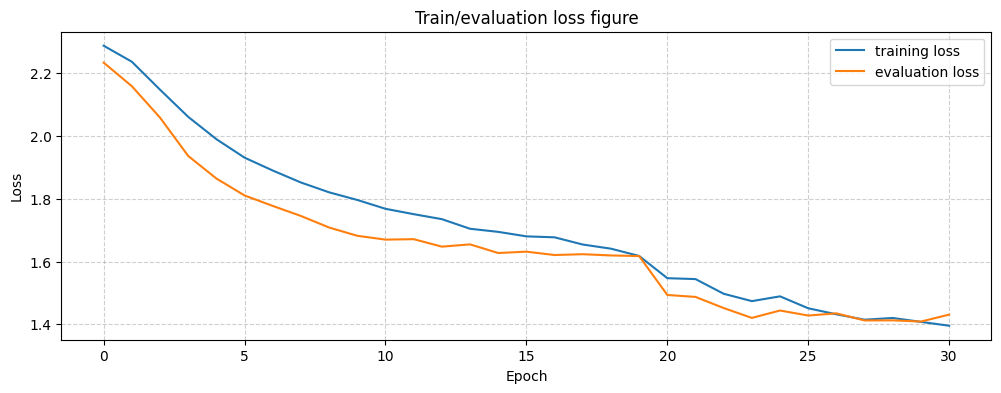

In [72]:
plt.figure(figsize=(12, 4))
plt.plot(training_history['train_loss'], label = 'training loss')
plt.plot(training_history['val_loss'], label = 'evaluation loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Train/evaluation loss figure')
plt.grid(alpha=0.6, linestyle='--')
plt.legend()
plt.savefig('../img/training_evaluation_loss.png')

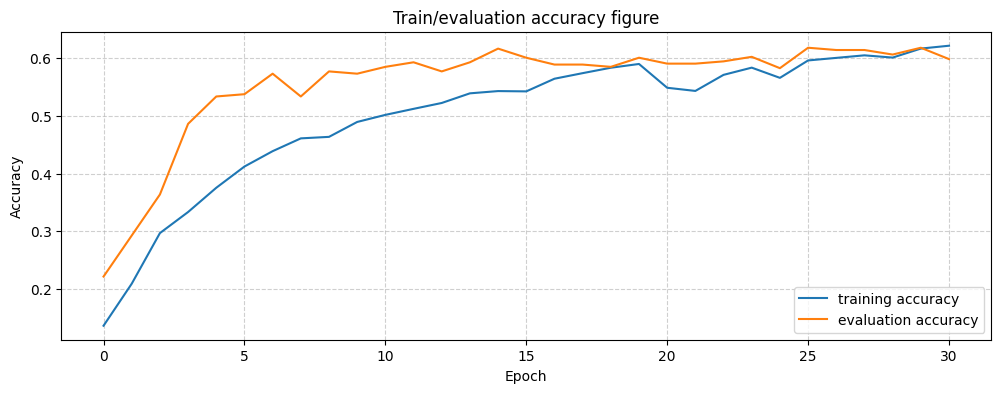

In [76]:
plt.figure(figsize=(12, 4))
plt.plot(training_history['train_acc'], label = 'training accuracy')
plt.plot(training_history['val_acc'], label = 'evaluation accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Train/evaluation accuracy figure')
plt.grid(alpha=0.6, linestyle='--')
plt.legend()
plt.savefig('../img/training_evaluation_accuracy.png')

## 2. Testing Analysis

In [71]:
result_path = r'..\models\checkpoints\detailed_eval_report.csv'
result = pd.read_csv(result_path)
print(result.head())

   True_Label  Pred_Label  Confidence  Correct
0  brush_hair  brush_hair      0.3329     True
1  brush_hair         sit      0.2588    False
2  brush_hair  brush_hair      0.5606     True
3  brush_hair  brush_hair      0.7567     True
4  brush_hair  brush_hair      0.9215     True


### 2.1. Confusion Matrix

In [74]:
def plot_cm_with_analysis(df, error_ratio_threshold=0.2):
    classes = sorted(df['True_Label'].unique())
    cm = confusion_matrix(df['True_Label'], df['Pred_Label'], labels=classes)
    cm_sum = np.sum(cm, axis=1, keepdims=True)
    cm_perc = np.divide(cm.astype('float'), cm_sum, out=np.zeros_like(cm.astype('float')), where=cm_sum!=0) * 100

    print("="*80)
    print(f"ANALYSIS: MISCLASSIFICATIONS VS. CORRECT PREDICTIONS (Threshold: >={error_ratio_threshold*100}%)")
    print("="*80)
    
    found_any = False
    for i, class_name in enumerate(classes):
        correct_count = cm[i, i] 
        
        major_errors = []
        for j, pred_name in enumerate(classes):
            if i == j: continue
            
            wrong_count = cm[i, j]
            if wrong_count == 0: continue
            
            if correct_count == 0:
                ratio = float('inf')
                major_errors.append(f"{pred_name} (Count: {wrong_count}, Ratio: INF)")
            else:
                ratio = wrong_count / correct_count
                if ratio >= error_ratio_threshold:
                    major_errors.append(f"{pred_name} (Count: {wrong_count}, Ratio: {ratio:.2f})")
        
        if major_errors:
            found_any = True
            header = f"❌ {class_name:15} [Correct: {correct_count}]"
            print(f"{header} | Over-threshold errors: {', '.join(major_errors)}")
    
    if not found_any:
        print(f"✅ Your model is solid. No error type exceeds {error_ratio_threshold*100}% of the correct predictions.")
    print("="*80 + "\n")

    plt.figure(figsize=(14, 11))
    annot = np.empty_like(cm).astype(str)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            c, p = cm[i, j], cm_perc[i, j]
            annot[i, j] = f'{c}\n({p:.1f}%)' if c > 0 else '0'
    sns.heatmap(cm_perc, annot=annot, fmt='', cmap='Blues', xticklabels=classes, yticklabels=classes)
    plt.title('Confusion Matrix Analysis')
    plt.savefig('../img/confusion_matrix.png')
    plt.show()

ANALYSIS: MISCLASSIFICATIONS VS. CORRECT PREDICTIONS (Threshold: >=50.0%)
❌ eat             [Correct: 4] | Over-threshold errors: drink (Count: 7, Ratio: 1.75), sit (Count: 2, Ratio: 0.50)
❌ sit             [Correct: 4] | Over-threshold errors: drink (Count: 2, Ratio: 0.50), stand (Count: 3, Ratio: 0.75), walk (Count: 9, Ratio: 2.25)
❌ stand           [Correct: 0] | Over-threshold errors: brush_hair (Count: 2, Ratio: INF), drink (Count: 3, Ratio: INF), eat (Count: 1, Ratio: INF), pick (Count: 2, Ratio: INF), push (Count: 2, Ratio: INF), sit (Count: 5, Ratio: INF), walk (Count: 8, Ratio: INF)



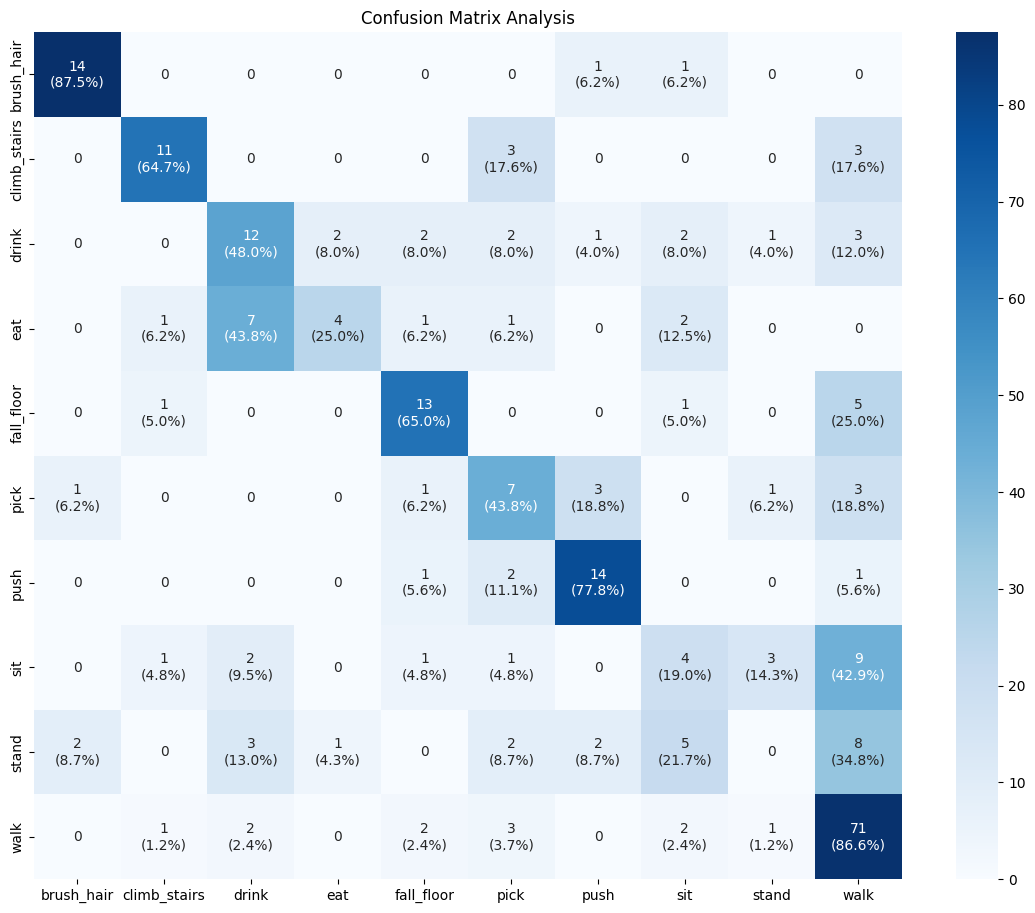

In [75]:
plot_cm_with_analysis(result, error_ratio_threshold=0.5)

### 2.2. Inference result analysis

In [29]:
from sklearn.metrics import f1_score, classification_report

f1_weighted = f1_score(result['True_Label'], result['Pred_Label'], average='weighted')

f1_per_class = f1_score(result['True_Label'], result['Pred_Label'], average=None)

In [30]:
print(f"F1-Score (Weighted): {f1_weighted:.4f}")
print("-" * 30)
print("Detailed report:")
report = classification_report(result['True_Label'], result['Pred_Label'])
print(report)

F1-Score (Weighted): 0.5575
------------------------------
Detailed report:
              precision    recall  f1-score   support

  brush_hair       0.82      0.88      0.85        16
climb_stairs       0.73      0.65      0.69        17
       drink       0.46      0.48      0.47        25
         eat       0.57      0.25      0.35        16
  fall_floor       0.62      0.65      0.63        20
        pick       0.33      0.44      0.38        16
        push       0.67      0.78      0.72        18
         sit       0.24      0.19      0.21        21
       stand       0.00      0.00      0.00        23
        walk       0.69      0.87      0.77        82

    accuracy                           0.59       254
   macro avg       0.51      0.52      0.51       254
weighted avg       0.54      0.59      0.56       254



## 3. Conclusion

### 3.1. Training

The training curves demonstrate a highly stable process with `no overfitting`, characterized by validation metrics initially outperforming training metrics due to aggressive regularization. While the convergence in the final epochs and the scheduler-induced loss reduction at epoch 20 indicate a healthy progression, `the accuracy plateau at 60%` suggests a performance ceiling. Consequently, reducing regularization strength is necessary to break this threshold in future iterations.

### 3.2. Inference result

#### 3.2.1. Strength

- **Weighted Loss Impact**: Significantly improved Recall for underrepresented classes (e.g., brush_hair, drink).
- **Top Performance (brush_hair)**: Achieved high F1-score (`~0.85`), demonstrating strong capability in learning distinctive motion patterns.

#### 3.2.2. Weakness

- **Motion Bias (stand = 0%)**: Static actions lack significant temporal motion, leading to misclassification as sit or walk.
- **Inter-class Similarity (eat vs. drink)**: High ambiguity due to shared "hand-to-mouth" gestures. Low resolution (224px) prevents distinguishing fine-grained objects (spoon vs. cup).